STA 5735 Assignment 2 Hope Mullins

In [8]:
import os
os.chdir('C:/ucf_classes/sta_5735')

QUESTION 1

To create a SQLite database in python, we need to import sqlite3, as well
as open a sqlite database connection. Due to the fact that we are working
with what is clearly store data, let's call this database "store.db". 

In [9]:
import csv
import sqlite3
import pandas as pd

In [10]:
conn = sqlite3.connect("store.db")
cu = conn.cursor()

Question 1

part a

First, we'll begin by loading in the specified csv files, 'customers.csv',
'order_items.csv', 'orders.csv', and 'products.csv', into a Pandas DataFrame.

In [11]:
customers = pd.read_csv('customers.csv')
items = pd.read_csv('order_items.csv')
orders = pd.read_csv('orders.csv')
products = pd.read_csv('products.csv')

In order to create a table for each file, we must use the execute() function,
acknowledging the names of our tables and their columns.

In [12]:
cu.execute('''
          CREATE TABLE IF NOT EXISTS customers (
              customer_id int,
              name text,
              email text,
              PRIMARY KEY (customer_id))
          ''')

In [13]:
cu.execute('''
          CREATE TABLE IF NOT EXISTS orders (
              order_id int,
              customer_id int,
              order_date text,
              PRIMARY KEY (order_id),
              FOREIGN KEY (customer_id) REFERENCES customers (customer_id))
          ''')   

In [14]:
cu.execute('''
          CREATE TABLE IF NOT EXISTS items (
              order_item_id int,
              order_id int,
              product_id int,
              quantity int,
              price real,
              PRIMARY KEY (order_item_id),
              FOREIGN KEY (order_id) REFERENCES orders (order_id))
          ''')

In [15]:
cu.execute('''
          CREATE TABLE IF NOT EXISTS products (
              product_id int,
              product_name text,
              category text,
              price real,
              PRIMARY KEY (product_id),
              FOREIGN KEY (product_id) REFERENCES items (product_id))
          ''')

In [16]:
conn.commit()

To fill the tables/database with the data in our files, we may utilize the
to_sql method.

In [17]:
customers.to_sql('customers', conn, if_exists = 'replace', index = False)

20

In [18]:
items.to_sql('items', conn, if_exists = 'replace', index = False)

70

In [19]:
orders.to_sql('orders', conn, if_exists = 'replace', index = False)

40

In [20]:
products.to_sql('products', conn, if_exists = 'replace', index = False)

10

In [21]:
conn.commit()

part b

To list all customers and any order they may have placed, we should use a LEFT
JOIN. This operation will retrieve all records from the customers table and the
corresponding records in the orders table, returning NULL for the customers who
placed no orders. However, because we are working in python, we may see "None"
or "NaN" instead of "NULL". Moreover, by placing the information in a Pandas 
DataFrame, we can maintain the column names and allow everything to appear in a
more organized manner.

In [22]:
results = cu.execute('''SELECT c.name, o.order_id, o.order_date
                     FROM customers c
                     LEFT JOIN orders o ON c.customer_id = o.customer_id
                     ''').fetchall()

In [23]:
columns = [d[0] for d in cu.description]
results1 = pd.DataFrame(results, columns = columns)
print(results1)

          name  order_id  order_date
0    Customer1       1.0  2024-11-28
1    Customer2      17.0  2024-11-25
2    Customer2      30.0  2024-12-24
3    Customer3      10.0  2024-09-28
4    Customer3      22.0  2025-01-05
5    Customer3      29.0  2024-11-20
6    Customer3      33.0  2024-10-08
7    Customer4       9.0  2025-02-12
8    Customer4      12.0  2025-01-18
9    Customer4      20.0  2024-09-07
10   Customer4      35.0  2025-01-07
11   Customer5       6.0  2024-09-04
12   Customer6       2.0  2024-12-02
13   Customer6      40.0  2024-11-05
14   Customer7       7.0  2024-09-09
15   Customer7      28.0  2024-12-12
16   Customer8      31.0  2025-02-14
17   Customer8      34.0  2024-12-12
18   Customer9       5.0  2024-12-24
19   Customer9      16.0  2024-11-04
20   Customer9      37.0  2024-10-26
21  Customer10      24.0  2024-12-09
22  Customer10      32.0  2025-01-07
23  Customer11       4.0  2024-09-12
24  Customer11       8.0  2024-09-18
25  Customer12      13.0  2024-10-17
2

We can see that of the twenty customers we have data on, customers 16 and 17 did
not make any orders. Additionally, some of the customers made multiple orders,
so we should be able to aggregate some data relating to that. Note that we need
not include the 'customer_id' variable as it offers no extra information that we
do not obtain from simply having the customers' names. The ID serves as a unique
identifier, a primary key, that we use to join our two tables together.

part c

Now, we might list the items in each order with their product information. 

In [24]:
results = cu.execute(''' SELECT i.order_id, quantity, i.price,
                     p.product_name, p.category
                     FROM items i
                     JOIN products p ON i.product_id = p.product_id
                     ''').fetchall()

In [25]:
columns = [d[0] for d in cu.description]
results2 = pd.DataFrame(results, columns = columns)
print(results2)

    order_id  quantity  price product_name     category
0          1         2  12.39     Product5        Books
1          2         5  29.84     Product9  Electronics
2          3         4  63.03    Product10         Toys
3          3         4  63.03    Product10         Toys
4          4         2  55.48     Product4        Books
..       ...       ...    ...          ...          ...
65        38         2  47.97     Product1  Electronics
66        39         4  47.97     Product1  Electronics
67        39         4  12.39     Product5        Books
68        40         5  68.49     Product7  Electronics
69        40         2  59.04     Product8         Toys

[70 rows x 5 columns]


Similar to part b, I did not include the 'product_id' variable in the output because
it is only necessary in the sense that it allows us to join our 'items' table and
'products' table, but it does not offer additional information since we included the
variable 'product_name'. 

part d

Now, we might attempt to get complete information on each order by joining all table data. If we desire to see all the information, then we should use left join, which returns all data regardless of if there is a matching ID for every variable or not.

In [26]:
results = cu.execute('''SELECT o.order_id, o.order_date, c.name, c.email,  
                     i.order_item_id, p.product_name, p.category, p.price,
                     i.quantity
                     FROM orders o
                     LEFT JOIN customers c ON o.customer_id = c.customer_id
                     LEFT JOIN items i ON o.order_id = i.order_id
                     LEFT JOIN products p ON i.product_id = p.product_id
                     ''').fetchall()

In [27]:
columns = [d[0] for d in cu.description]
results3 = pd.DataFrame(results, columns = columns)
print(results3)

    order_id  order_date        name                   email  order_item_id  \
0          1  2024-11-28   Customer1   customer1@example.com              1   
1          2  2024-12-02   Customer6   customer6@example.com              2   
2          3  2025-01-08  Customer14  customer14@example.com              3   
3          3  2025-01-08  Customer14  customer14@example.com              4   
4          4  2024-09-12  Customer11  customer11@example.com              5   
..       ...         ...         ...                     ...            ...   
65        38  2024-11-21  Customer15  customer15@example.com             66   
66        39  2024-09-19  Customer12  customer12@example.com             67   
67        39  2024-09-19  Customer12  customer12@example.com             68   
68        40  2024-11-05   Customer6   customer6@example.com             69   
69        40  2024-11-05   Customer6   customer6@example.com             70   

   product_name     category  price  quantity  
0  

Opening these results in Data Wrangler allows us to see the entire desired table. Again, some ID variables are not included for the sake of appearance and to demonstrate which variables are truly important. But the information presented shows each customer's name and email, as well as information related to their orders (date, product, product category, etc.). We can see that some customers ordered multiple times, while a few did not order anything at all.

part e

Because some customers made multiple orders, we should count up the number of orders each customer made (for some it will be 0) and the total amount each individual spent. This may be accomplished with GROUP BY, so we may now see some aggregated information.

In [28]:
results = cu.execute(''' SELECT c.name, COUNT(o.order_id) AS order_count,
                         SUM(i.price * i.quantity) AS total_amount_spent
                         FROM customers c
                         LEFT JOIN orders o ON c.customer_id = o.customer_id
                         LEFT JOIN items i ON o.order_id = i.order_id
                         GROUP BY c.name
                         ''').fetchall()

In [29]:
columns = [d[0] for d in cu.description]
results4 = pd.DataFrame(results, columns = columns)
print(results4)

          name  order_count  total_amount_spent
0    Customer1            1               24.78
1   Customer10            2              290.08
2   Customer11            4              323.56
3   Customer12            8              832.95
4   Customer13            5              311.79
5   Customer14            2              504.24
6   Customer15            3              379.81
7   Customer16            0                 NaN
8   Customer17            0                 NaN
9   Customer18            4              372.28
10  Customer19            3              492.91
11   Customer2            3              628.20
12  Customer20            2              108.62
13   Customer3            5              632.67
14   Customer4            9              889.59
15   Customer5            1              118.72
16   Customer6            3              609.73
17   Customer7            5             1047.27
18   Customer8            5              594.19
19   Customer9            5             

part f

Finally, we may observe the quantities of each product sold across all orders. We will still utilize the GROUP BY statement:

In [30]:
results = cu.execute(''' SELECT p.product_name, SUM(i.quantity) AS total_quantity
                         FROM products AS p
                         JOIN items i ON p.product_id = i.product_id
                         GROUP BY p.product_name
                         ''').fetchall()

In [31]:
columns = [d[0] for d in cu.description]
results5 = pd.DataFrame(results, columns = columns)
print(results5)

  product_name  total_quantity
0     Product1              14
1    Product10              23
2     Product2              34
3     Product3              16
4     Product4              21
5     Product5              24
6     Product6              10
7     Product7              25
8     Product8              23
9     Product9              26


In [32]:
conn.close()

QUESTION 2

part a

To begin, let's load the specified data into a Pandas DataFrame.

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score, auc
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV


In [34]:
shark = pd.read_csv('global_shark_attacks.csv')

First, before we begin making any predictions, we need to clean up our data and ensure the variables we use are relevant to the prediction process. Knowing this, we should observe the variables and attempt to understand them better, so let's first get some information on our data, including what variables we're using, how many unique values there are, how many null values there are, and the type of data each column is:

In [35]:
shark.info()
len(shark)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6890 entries, 0 to 6889
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       6587 non-null   object 
 1   year       6758 non-null   float64
 2   type       6871 non-null   object 
 3   country    6839 non-null   object 
 4   area       6409 non-null   object 
 5   location   6325 non-null   object 
 6   activity   6304 non-null   object 
 7   name       6670 non-null   object 
 8   sex        6318 non-null   object 
 9   age        3903 non-null   object 
 10  fatal_y_n  6890 non-null   object 
 11  time       3372 non-null   object 
 12  species    3772 non-null   object 
dtypes: float64(1), object(12)
memory usage: 699.9+ KB


6890

In [36]:
na_number = shark.isnull().sum()
print("Number of NA values in each column")
print(na_number)

Number of NA values in each column
date          303
year          132
type           19
country        51
area          481
location      565
activity      586
name          220
sex           572
age          2987
fatal_y_n       0
time         3518
species      3118
dtype: int64


With this, we know it might be helpful to eliminate some of these variables from our prediction model (otherwise, we'd have a very large amount of NAs to work with, which might mess with our prediction). Considering that, three columns we should definitely drop are 'age', 'time', and 'species'. While 'time' and 'age' might be relevant in predicting the activity an individual is doing when a shark attacks, there are about 3000 null values in the age column, and over that amount of null values in the time column (the type of species is most likely not a great predictor for 'activity'). Moreover, the name of an individual will not have an impact on 'activity', so that column should be dropped as well when performing our calculations/prediction models.

In [37]:
shark = shark.drop(['age', 'time', 'species', 'name'], axis = 1)

In [38]:
na_number = shark.isnull().sum()
print("Number of NA values in each column")
print(na_number)

Number of NA values in each column
date         303
year         132
type          19
country       51
area         481
location     565
activity     586
sex          572
fatal_y_n      0
dtype: int64


In cleaning our data, we could also examine the 'activity' column specifically. Because we have 6890 observations, deleting the rows where 'activity' is null should not signficantly affect our prediction model, so let's do that:

In [39]:
shark = shark.dropna(subset=['activity'])

In [40]:
na_number = shark.isnull().sum()
print("Number of NA values in each column")
print(na_number)

Number of NA values in each column
date         248
year         110
type          14
country       43
area         395
location     472
activity       0
sex          419
fatal_y_n      0
dtype: int64


Additionally, in cleaning our data, it would be extremely important to determine how many unique values there are in each column.

In [41]:
unique = shark.nunique()
print("Unique Counts Per Column:")
print(unique)

Unique Counts Per Column:
date         5175
year          233
type           11
country       208
area          806
location     4146
activity     1553
sex             6
fatal_y_n       9
dtype: int64


The 'year' variable could have some importance in explaining 'activity' because trends in activities could change over time. However, specific dates may not matter as much. We could adjust the 'date' column to account for months/seasons compared to days.

In [42]:
shark['date'] = shark['date'].str[5:]
shark['date'] = shark['date'].str[:-3]
shark = shark.rename(columns={'date': 'month'})

In [43]:
unique = shark['month'].unique()
print(unique)

['05' '04' '10' '01' '08' '02' '12' '11' '07' '06' '09' '03' nan '7']


In [44]:
shark = shark.dropna(subset=['month'])
shark['month'] = shark['month'].replace('7', '07')
unique = shark['month'].unique()
print(unique)

['05' '04' '10' '01' '08' '02' '12' '11' '07' '06' '09' '03']


In [45]:
conditions = [
    shark['month'].isin(['12', '01', '02']),
    shark['month'].isin(['03', '04', '05']),
    shark['month'].isin(['06', '07', '08']),
    shark['month'].isin(['09', '10', '11'])
]

choices = ['Winter', 'Spring', 'Summer', 'Fall']

shark['season'] = np.select(conditions, choices)

In [46]:
unique = shark.nunique()
print("Unique Counts Per Column:")
print(unique)

Unique Counts Per Column:
month          12
year          228
type           11
country       196
area          763
location     4010
activity     1463
sex             6
fatal_y_n       9
season          4
dtype: int64


Looking at the columns now, a final variable we might drop should be 'location', as it has 4010 unique values. Thus, it would likely not do a great job at predicting 'activity'. While it is more specific, we already have the columns 'country' and 'area', which will offer some of the same information. 

In [47]:
shark = shark.drop(['location'], axis = 1)

With these last columns, we should get rid of the rows with empty values. 

In [48]:
shark = shark.dropna()

In [49]:
unique = shark.nunique()
print("Unique Counts Per Column:")
print(unique)

len(shark)

Unique Counts Per Column:
month          12
year          210
type            9
country       155
area          694
activity     1202
sex             6
fatal_y_n       8
season          4
dtype: int64


5317

Now, we are left with 5317 observations, which is still a significant amount of data to work with. Since we want to predict 'activity', we can already guess that it will be difficult to create an accurate prediction model considering 'activity' has 1202 unique values. To combat this, we could categorize values that do not show up as prominantly in each column as "other" (and we should do this with any variable containing too many values). Alternatively, we may need to combine values together because they represent the same thing (for example, any value in the 'activity' column that contains the word "swim" should be automatically considered "swimming"). 

First, let's start with the variables that have the least amount of unique values, such as type:

In [50]:
unique = shark['type'].unique()
print(unique)

['Unprovoked' 'Provoked' 'Invalid' 'Watercraft' 'Sea Disaster'
 'Questionable' 'Unverified' '?' 'Under investigation']


In [51]:
top_10_shark = shark['type'].value_counts(normalize=True).head(10) * 100

top_10_shark = top_10_shark.reset_index()
top_10_shark.columns = ['type' + '_value', 'percentage']

print(top_10_shark)

            type_value  percentage
0           Unprovoked   79.142374
1             Provoked    9.460222
2              Invalid    6.601467
3           Watercraft    2.332142
4         Sea Disaster    2.200489
5         Questionable    0.206884
6           Unverified    0.018808
7                    ?    0.018808
8  Under investigation    0.018808


For simplicity, it seems that the last four values and "Invalid" could be combined into one:

In [52]:
values_to_replace = ['Under investigation', '?', 'Unverified', 'Questionable', 'Invalid']
shark['type'] = shark['type'].replace(values_to_replace, 'Other')

Moving on to sex:

In [53]:
unique = shark['sex'].unique()
print(unique)

['M' 'F' 'N' '.' 'M x 2' 'lli']


In [54]:
top_10_shark = shark['sex'].value_counts(normalize=True).head(10) * 100

top_10_shark = top_10_shark.reset_index()
top_10_shark.columns = ['sex' + '_value', 'percentage']

print(top_10_shark)

  sex_value  percentage
0         M   87.417717
1         F   12.507053
2         N    0.018808
3         .    0.018808
4     M x 2    0.018808
5       lli    0.018808


Because "N", ".", "M x 2", and "lli" were all clearly mistakenly entered into the "sex" column and they do not affect a large portion of the data, we will simply categorize those values as "Unknown":

In [55]:
values_to_replace = ['N', '.', 'M x 2', 'lli']
shark['sex'] = shark['sex'].replace(values_to_replace, 'Unknown')

Moving on to fatal_y_n:

In [56]:
unique = shark['fatal_y_n'].unique()
print(unique)

['Y' 'N' 'UNKNOWN' 'Y x 2' 'F' 'n' '2017.0' 'Nq']


In [57]:
top_10_shark = shark['fatal_y_n'].value_counts(normalize=True).head(10) * 100

top_10_shark = top_10_shark.reset_index()
top_10_shark.columns = ['fatal_y_n' + '_value', 'percentage']

print(top_10_shark)

  fatal_y_n_value  percentage
0               N   73.744593
1               Y   19.315403
2         UNKNOWN    6.827158
3               F    0.037615
4           Y x 2    0.018808
5               n    0.018808
6          2017.0    0.018808
7              Nq    0.018808


While lowercase "n" most likely represents "N", the other values excluding "N", "Y", and "UNKNOWN" are less interpretable. Therefore, let's categorize "F", "Y x 2", "2017.0", and "Nq" as "UNKNOWN" as well:

In [58]:
values_to_replace = ["n"]
shark['fatal_y_n'] = shark['fatal_y_n'].replace(values_to_replace, "N")

values_to_replace = ["F", "Y x 2", "2017.0", "Nq"]
shark['fatal_y_n'] = shark['fatal_y_n']. replace(values_to_replace, "UNKNOWN")

Now we have the variables with the most unique values left:

In [59]:
unique = shark.nunique()
print("Unique Counts Per Column:")
print(unique)

Unique Counts Per Column:
month          12
year          210
type            5
country       155
area          694
activity     1202
sex             3
fatal_y_n       3
season          4
dtype: int64


Looking at country, let's observe the most mentioned: 

In [60]:
top_20_shark = shark['country'].value_counts(normalize=True).head(20) * 100

top_20_shark = top_20_shark.reset_index()
top_20_shark.columns = ['country' + '_value', 'percentage']

print(top_20_shark)

       country_value  percentage
0                USA   41.997367
1          AUSTRALIA   22.343427
2       SOUTH AFRICA    9.215723
3        NEW ZEALAND    2.162874
4   PAPUA NEW GUINEA    1.824337
5             BRAZIL    1.749107
6            BAHAMAS    1.711491
7             MEXICO    1.466993
8              ITALY    0.846342
9            REUNION    0.789919
10              FIJI    0.695881
11     NEW CALEDONIA    0.677074
12        MOZAMBIQUE    0.658266
13             SPAIN    0.639458
14              CUBA    0.620651
15       PHILIPPINES    0.620651
16  FRENCH POLYNESIA    0.564228
17             EGYPT    0.564228
18            PANAMA    0.488998
19             INDIA    0.432575


Let's categorize all values that do not fall into these top ten countries as "Other":

In [61]:
top_values = shark['country'].value_counts().nlargest(20).index
shark['country'] = shark['country'].apply(lambda x: x if x in top_values else 'Other')

Repeating this for "area":

In [62]:
top_30_shark = shark['area'].value_counts(normalize=True).head(30) * 100

top_30_shark = top_30_shark.reset_index()
top_30_shark.columns = ['area' + '_value', 'percentage']

print(top_30_shark)

               area_value  percentage
0                 Florida   19.766786
1         New South Wales    8.200113
2                  Hawaii    5.661087
3              California    5.454203
4              Queensland    5.397781
5       Western Australia    3.498213
6           KwaZulu-Natal    3.441790
7   Eastern Cape Province    2.839947
8   Western Cape Province    2.783525
9          South Carolina    2.614256
10         North Carolina    1.880760
11               Victoria    1.523415
12        South Australia    1.523415
13                  Texas    1.354147
14             Pernambuco    1.278917
15          Torres Strait    1.147263
16           North Island    1.147263
17             New Jersey    0.846342
18               New York    0.827534
19           South Island    0.695881
20                 Oregon    0.583036
21          Abaco Islands    0.545420
22               Tasmania    0.545420
23       Central Province    0.432575
24     Northern Territory    0.413767
25          

In [63]:
top_values = shark['area'].value_counts().nlargest(30).index
shark['area'] = shark['area'].apply(lambda x: x if x in top_values else 'Other')

For the 'activity' column:

In [64]:
top_50_shark = shark['activity'].value_counts(normalize=True).head(50) * 100

top_50_shark = top_50_shark.reset_index()
top_50_shark.columns = ['activity' + '_value', 'percentage']

print(top_50_shark)

                    activity_value  percentage
0                          Surfing   20.161745
1                         Swimming   17.246568
2                          Fishing    6.657890
3                     Spearfishing    6.112469
4                           Wading    3.028023
5                          Bathing    2.633064
6                         Standing    2.106451
7                       Snorkeling    2.087643
8                           Diving    1.805529
9                     Scuba diving    1.448185
10                   Body boarding    1.147263
11                    Body surfing    0.959188
12                 Boogie boarding    0.771112
13                        Kayaking    0.733496
14                  Treading water    0.601843
15                     Free diving    0.526613
16                     Surf skiing    0.432575
17                    Pearl diving    0.432575
18                     Windsurfing    0.338537
19                 Boogie Boarding    0.319729
20           

We can see even among the top fifty mentioned activities, there is much repetitiveness. For example, "Body boarding" and "Body Boarding" reference the same activity, but because of the change in case of the second word, they are counted separately. Therefore, we can work with some of these most frequently mentioned values to try and simplify the activities. Naturally, there are too many activities to do this for every value, but an attempt at this might assist in prediction.

In [65]:
pattern = r'sw|swim|swam'

shark['activity'] = np.where(
    (shark['activity'] != 'Swimming') & (shark['activity'].str.contains(pattern, case=False, na=False)), 
    'Swimming', 
    shark['activity']
)

In [66]:
pattern = r'surf|wave'

shark['activity'] = np.where(
    (shark['activity'] != 'Surfing') & (shark['activity'].str.contains(pattern, case=False, na=False)), 
    'Surfing', 
    shark['activity']
)

In [67]:
pattern = r'div'

shark['activity'] = np.where(
    (shark['activity'] != 'Diving') & (shark['activity'].str.contains(pattern, case=False, na=False)), 
    'Diving', 
    shark['activity']
)

In [68]:
pattern = r'fish'

shark['activity'] = np.where(
    (shark['activity'] != 'Fishing') & (shark['activity'].str.contains(pattern, case=False, na=False)), 
    'Fishing', 
    shark['activity']
)

In [69]:
pattern = r'board|SUP'

shark['activity'] = np.where(
    (shark['activity'] != 'Boarding') & (shark['activity'].str.contains(pattern, case=False, na=False)), 
    'Boarding (Body Boarding, Paddle Boarding, etc.)', 
    shark['activity']
)

In [70]:
pattern = r'float'

shark['activity'] = np.where(
    (shark['activity'] != 'Floating') & (shark['activity'].str.contains(pattern, case=False, na=False)), 
    'Floating', 
    shark['activity']
)

In [71]:
pattern = r'wreck'

shark['activity'] = np.where(
    (shark['activity'] != 'Shipwreck') & (shark['activity'].str.contains(pattern, case=False, na=False)), 
    'Shipwreck', 
    shark['activity']
)

In [72]:
pattern = r'row|canoe|kayak'

shark['activity'] = np.where(
    (shark['activity'] != 'Rowing') & (shark['activity'].str.contains(pattern, case=False, na=False)), 
    'Rowing', 
    shark['activity']
)

In [73]:
pattern = r'bath'

shark['activity'] = np.where(
    (shark['activity'] != 'Bathing') & (shark['activity'].str.contains(pattern, case=False, na=False)), 
    'Bathing', 
    shark['activity']
)

In [74]:
top_50_shark = shark['activity'].value_counts(normalize=True).head(50) * 100

top_50_shark = top_50_shark.reset_index()
top_50_shark.columns = ['activity' + '_value', 'percentage']

print(top_50_shark)

                                       activity_value  percentage
0                                             Surfing   25.578334
1                                            Swimming   21.120933
2                                             Fishing   17.152530
3                                              Diving    9.102878
4     Boarding (Body Boarding, Paddle Boarding, etc.)    4.589054
5                                              Wading    3.028023
6                                             Bathing    2.952793
7                                            Standing    2.106451
8                                          Snorkeling    2.087643
9                                              Rowing    1.278917
10                                           Floating    0.940380
11                                     Treading water    0.601843
12                                          Shipwreck    0.413767
13                                            Walking    0.300922
14        

Almost 90% of the activities listed are contained in just the top ten activities now. Due to this, we will change everything that is not one of the top fifteen activities to "Other":

In [75]:
top_values = shark['activity'].value_counts().nlargest(15).index
shark['activity'] = shark['activity'].apply(lambda x: x if x in top_values else 'Other')

In [76]:
unique = shark.nunique()
print("Unique Counts Per Column:")
print(unique)

Unique Counts Per Column:
month         12
year         210
type           5
country       21
area          31
activity      16
sex            3
fatal_y_n      3
season         4
dtype: int64


The only variable now that still contains many unique values is "year". We could keep this, but I think converting this to decades would be more useful:

In [77]:
shark['year'] = ((shark['year'] // 10 * 10).astype(int).astype(str) + 's')
shark = shark.rename(columns={'year': 'decade'})

Having cleaned up our data significantly, we should now work on predicting the 'activity'. This will involve identifying the dependent variable as "y" and all else as "x". We should then convert the variables into dummies using the get.dummies() function. Additionally, through some of my googling, I found that the LabelEncoder() function replaces categorical values with numerical ones, and I utilize this function for the dependent variable.

In [78]:
LE = LabelEncoder()
shark['activity_encoded'] = LE.fit_transform(shark['activity'])
y = shark['activity_encoded']

In [79]:
X = shark.drop(columns=['activity', 'activity_encoded'])
X_encoded = pd.get_dummies(X, drop_first=True)

Now, we can obtain our training and testing data using train_test_split().

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42
)

Different methods may be used to predict the activity. Beginning with logistic regression:

In [81]:
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, multi_class='multinomial')

In [82]:
y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy:.5f}")

Logistic Regression Accuracy: 0.45238


Decision Trees:

In [83]:
dt = DecisionTreeClassifier(random_state = 42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [84]:
y_pred_dt = dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt:.5f}")

Decision Tree Accuracy: 0.35714


Support Vector Machine:

In [85]:
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)

SVC(random_state=42)

In [86]:
y_pred_svm = svm.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {accuracy_svm:.5f}")

SVM Accuracy: 0.45990


Random Forest:

In [87]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [88]:
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of predicting 'activity': {accuracy:.5f}")

Accuracy of predicting 'activity': 0.42356


None of the accuracy levels are particularly high. The best performing model is that of the support vector machine using the radial basis function kernel, at 0.46 accuracy. Logistic regression isn't too far behind with an accuracy of 0.45. However, neither of these are good.

part c

Now let's predict "Swimming" or not for the activity, meaning we are dealing with binary classification. We should now ensure our dependent variable has values of only 1 (if the activity is "Swimming") and 0 (if the activity is not "Swimming"). 

In [89]:
shark['Swimming'] = shark['activity'].apply(lambda x: 1 if x == "Swimming" else 0)
y = shark['Swimming']

X = shark.drop(columns=['activity', 'Swimming'])
X_encoded = pd.get_dummies(X, drop_first=True)


Repeating the process of splitting the data into training and testing:

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
    )

Beginning with logistic regression:

In [91]:
log_reg = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [92]:
y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.5f}")

Accuracy: 0.87688


In [93]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[764  47]
 [ 84 169]]


In [94]:
y_prob = log_reg.predict_proba(X_test)[:, 1]  
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.5f}")

ROC AUC: 0.95240


We can produce an ROC curve from this:

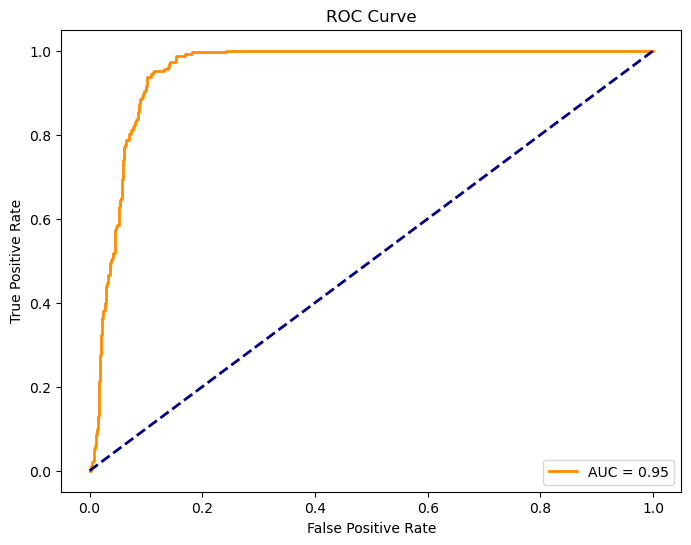

In [95]:
plt.figure(figsize = (8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

Additionally, we can observe other models and their accuracies.

Decision Tree:

In [96]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt:.5f}")

Decision Tree Accuracy: 1.00000


In [97]:
cm = confusion_matrix(y_test, y_pred_dt)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[811   0]
 [  0 253]]


Support Vector Machine:

In [98]:
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {accuracy_svm:.5f}")

SVM Accuracy: 0.96241


In [99]:
cm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[771  40]
 [  0 253]]


Random Forest:

In [100]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.5f}")

Random Forest Accuracy: 0.99530


In [101]:
cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[807   4]
 [  1 252]]


With all of this, working with binary classification performs significantly better than our previous attempts of predicting the activity when there are many potential options activity could be. The decision tree model achieved 100% accuracy when we predict "Swimming" versus not, while random forest almost reached that level of accuracy as well. The logistic regression model had an accuracy of 88% and the support vector machine model an accuracy of 96%.

part d

Now we will try to predict the age, which means we need to return to our original dataset and determine how it should be cleaned up this time.

In [102]:
shark2 = pd.read_csv('global_shark_attacks.csv')

In [103]:
na_number = shark2.isnull().sum()
print("Number of NA values in each column")
print(na_number)

Number of NA values in each column
date          303
year          132
type           19
country        51
area          481
location      565
activity      586
name          220
sex           572
age          2987
fatal_y_n       0
time         3518
species      3118
dtype: int64


Because so many of the values in the 'age' column are not usable to generate predictions, we need to eliminate those observations:

In [104]:
shark2 = shark2.dropna(subset=['age'])

In [105]:
na_number = shark2.isnull().sum()
print("Number of NA values in each column")
print(na_number)

Number of NA values in each column
date           48
year           15
type           10
country         9
area          134
location      163
activity      161
name           12
sex            38
age             0
fatal_y_n       0
time         1206
species      1482
dtype: int64


In [106]:
unique = shark2.nunique()
print("Unique Counts Per Column:")
print(unique)

Unique Counts Per Column:
date         3419
year          164
type            8
country       141
area          476
location     2663
activity      754
name         3489
sex             3
age           232
fatal_y_n       6
time          341
species      1115
dtype: int64


Some of the variables relevant for prediction of 'age' are different than those we needed to predict 'activity'. 'date' and 'year' do not seem like they would be very helpful in predicting the age of an individual. 'type' may be useful, as different age groups may be more risky than others. 'country', 'area', and 'location' are potentially good predictors, considering different regions may have different age demographics for shark attack victims (and some locations may attract different age demographics more than others). However, because 'location' contains so many unique values for a relatively small dataset, it would be better to drop this column like we did previously. Similarly, 'name' should be dropped because there are 3489 distinct values. 'activity' certainly seems relevant, as does 'sex'. 'fatal_y_n' and 'species' do not seem relevant at all, as both are dependent on the event itself. However, 'time' could have some relevance: older individuals will spend their time differently than younger ones, and the patterns of their activities may differ.

In [107]:
shark2 = shark2.drop(['date', 'year', 'location', 'name', 'fatal_y_n', 'species'], axis = 1)
shark2 = shark2.dropna()

In [108]:
unique = shark2.nunique()
print("Unique Counts Per Column:")
print(unique)

Unique Counts Per Column:
type          8
country      92
area        287
activity    466
sex           3
age         181
time        333
dtype: int64


The only variables that we did not keep for prediction in parts b and c were 'age' and 'time', so we will need to do some additional cleaning on those variables. But we may reuse the code we utilized previously to clean up the variables 'type', 'country', 'area', 'activity', and 'sex':

In [109]:
values_to_replace = ['Under investigation', '?', 'Unverified', 'Questionable', 'Invalid']
shark2['type'] = shark2['type'].replace(values_to_replace, 'Other')

In [110]:
values_to_replace = ['N', '.', 'M x 2', 'lli']
shark2['sex'] = shark2['sex'].replace(values_to_replace, 'Unknown')

In [111]:
top_values = shark2['country'].value_counts().nlargest(20).index
shark2['country'] = shark2['country'].apply(lambda x: x if x in top_values else 'Other')

In [112]:
top_values = shark2['area'].value_counts().nlargest(30).index
shark2['area'] = shark2['area'].apply(lambda x: x if x in top_values else 'Other')

In [113]:
pattern = r'sw|swim|swam'

shark2['activity'] = np.where(
    (shark2['activity'] != 'Swimming') & (shark2['activity'].str.contains(pattern, case=False, na=False)), 
    'Swimming', 
    shark2['activity']
)

In [114]:
pattern = r'surf|wave'

shark2['activity'] = np.where(
    (shark2['activity'] != 'Surfing') & (shark2['activity'].str.contains(pattern, case=False, na=False)), 
    'Surfing', 
    shark2['activity']
)

In [115]:
pattern = r'div'

shark2['activity'] = np.where(
    (shark2['activity'] != 'Diving') & (shark2['activity'].str.contains(pattern, case=False, na=False)), 
    'Diving', 
    shark2['activity']
)

In [116]:
pattern = r'fish'

shark2['activity'] = np.where(
    (shark2['activity'] != 'Fishing') & (shark2['activity'].str.contains(pattern, case=False, na=False)), 
    'Fishing', 
    shark2['activity']
)

In [117]:
pattern = r'board|SUP'

shark2['activity'] = np.where(
    (shark2['activity'] != 'Boarding') & (shark2['activity'].str.contains(pattern, case=False, na=False)), 
    'Boarding (Body Boarding, Paddle Boarding, etc.)', 
    shark2['activity']
)

In [118]:
pattern = r'float'

shark2['activity'] = np.where(
    (shark2['activity'] != 'Floating') & (shark2['activity'].str.contains(pattern, case=False, na=False)), 
    'Floating', 
    shark2['activity']
)

In [119]:
pattern = r'wreck'

shark2['activity'] = np.where(
    (shark2['activity'] != 'Shipwreck') & (shark2['activity'].str.contains(pattern, case=False, na=False)), 
    'Shipwreck', 
    shark2['activity']
)

In [120]:
pattern = r'row|canoe|kayak'

shark2['activity'] = np.where(
    (shark2['activity'] != 'Rowing') & (shark2['activity'].str.contains(pattern, case=False, na=False)), 
    'Rowing', 
    shark2['activity']
)

In [121]:
pattern = r'bath'

shark2['activity'] = np.where(
    (shark2['activity'] != 'Bathing') & (shark2['activity'].str.contains(pattern, case=False, na=False)), 
    'Bathing', 
    shark2['activity']
)

In [122]:
top_values = shark2['activity'].value_counts().nlargest(15).index
shark2['activity'] = shark2['activity'].apply(lambda x: x if x in top_values else 'Other')

In [123]:
unique = shark2.nunique()
print("Unique Counts Per Column:")
print(unique)

Unique Counts Per Column:
type          5
country      21
area         31
activity     16
sex           3
age         181
time        333
dtype: int64


To clean up 'age', we should note the kinds of values contained within the column.

In [124]:
unique = shark2['age'].unique()
print(unique)

['46' '38' '14.0' '53.0' '46.0' '17.0' '59.0' '60.0' '33.0' '21.0' '50.0'
 '6.0' '57.0' '13.0' '19.0' '12.0' '31.0' '9.0' '25.0' '32' '10' '47' '13'
 '20' '28' '42' '25' '45' '68' '14' '8' '34' '23' '19' '18' '31' '27' '49'
 '21' '26' '26.0' '18.0' '52.0' '27.0' '35' '5' '20.0' '32.0' '43.0'
 '29.0' '47.0' '48.0' '21, 34,24 & 35' '22.0' '15.0' '24.0' '36' '16.0'
 '60' '51' '54.0' '70.0' '23.0' '11.0' '74.0' '58.0' '40.0' '71' '63' '16'
 '43' '56' '48' '62' '22' '86' '37' '59' '54' '61' '40' '7' '15' '52'
 '30.0' '28.0' '39.0' '37.0' '42.0' '36.0' '34.0' '41.0' '20s' '35.0' 'F'
 '51.0' '60s' '64.0' '29' '17' '55' '24' '12 or 13' '12' '55.0' '10.0'
 '30' '53' '8.0' '50s' 'Teen' '9 & 60' '65' '40s' 'teen' '39' '49.0' '9'
 '30s' '73.0' '50' '38.0' '63.0' '44.0' '6' "20's" '44' '57' '69.0' '11'
 '41' '(adult)' '73' '33' '61.0' '30 & 32' '9 or 10' '70' '45.0' '58' '69'
 '33 & 26' '68.0' '74' '66' '71.0' '5.0' '25 or 28' '7.0' '13 or 18' '64'
 '8 or 10' '65.0' '77.0' '? & 19' '56.0' '84.0' '6

It is clear that values like "46" should be equivalent to "46.0". Additionally, it might help to delete the observations where more than one individual's age is listed, as well as the observations where age is not clearly specified (such as 'Teen' and 'teen'). What the code below does is convert the numeric strings to integers while removing the values that generate errors.

In [125]:
shark2['age'] = pd.to_numeric(shark2['age'], errors = "coerce")
shark2 = shark2.dropna(subset=['age']).astype({'age': int})

In [126]:
unique = shark2['age'].unique()
print(unique)

[46 38 14 53 17 59 60 33 21 50  6 57 13 19 12 31  9 25 32 10 47 20 28 42
 45 68  8 34 23 18 27 49 26 52 35  5 43 29 48 22 15 24 36 16 51 54 70 11
 74 58 40 71 63 56 62 86 37 61  7 30 39 41 64 55 65 73 44 69 66 77 84 75
  4  3 67 82]


In [127]:
shark2['time'].head(20)

0         10h10
2         11h30
6         16h00
7         08h00
9         10h30
10        16h00
11        12h00
13        11h30
14        16h30
16        16h00
18        06h15
19      Evening
21    Afternoon
22        18h00
23        15h30
24        15h00
25        10h00
27        13h30
29        15h40
32        12h00
Name: time, dtype: object

'time' appears to be a more complicated variable to work with as well. To simplify our prediction process, we should adjust the values so that something like "10h10" could be represented as 10 o'clock, as down to the very minute is too specific to work with (in other words, anything that falls from the range of 10:00-10:59 should be classified as 10). Additionally, values like "Evening" should be dropped. The code below accomplishes this by essentially removing the "h" and all trailing numbers while simultaneously dropping the values that produce errors.

In [128]:
shark2["time"] = shark2["time"].str.extract(r"(\d{1,2})h")[0]
shark2 = shark2.dropna(subset=["time"]).astype({"time": int}) 

In [129]:
unique = shark2['time'].unique()
print(unique)

[10 11 16  8 12  6 18 15 13  9 17 14  7 20 19  5 21  3  0  4 23  2 22  1]


In [130]:
unique = shark2.nunique()
print("Unique Counts Per Column:")
print(unique)

Unique Counts Per Column:
type         5
country     21
area        31
activity    16
sex          3
age         75
time        24
dtype: int64


With this significantly less messy dataset, we can begin working on our predictions of the variable 'age'. We want to build three different models and calculate the mean-squared error from each of those models, as well as note the most important variable from the relative importance. Defining our dependent and independent variables (note that age and time are already numerical and thus do not need to be converted to encoded/dummy values):

In [131]:
y = shark2['age']

X = shark2.drop(columns=['age'])
X_encoded = pd.get_dummies(X, drop_first=True)


In [132]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42
    )

Beginning with Decision Tree:

In [133]:
dt_params = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10]
}

dt_grid = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_params, scoring='neg_mean_squared_error', cv=5)
dt_grid.fit(X_train, y_train)

print(f"Best Decision Tree parameters: {dt_grid.best_params_}")

Best Decision Tree parameters: {'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}


In [134]:
dt_best = DecisionTreeRegressor(**dt_grid.best_params_, random_state=42)
dt_best.fit(X_train, y_train)
y_pred_dt_best = dt_best.predict(X_test)

In [135]:
mse_dt_best = mean_squared_error(y_test, y_pred_dt_best)
print(f"Tuned Decision Tree MSE: {mse_dt_best:.2f}")

Tuned Decision Tree MSE: 192.62


Random Forest:

In [136]:
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, scoring='neg_mean_squared_error', cv=3, n_jobs=-1)
rf_grid.fit(X_train, y_train)

print(f"Best Random Forest parameters: {rf_grid.best_params_}")

Best Random Forest parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}


In [137]:
rf_best = RandomForestRegressor(**rf_grid.best_params_, random_state=42)
rf_best.fit(X_train, y_train)
y_pred_rf_best = rf_best.predict(X_test)

In [138]:
mse_rf_best = mean_squared_error(y_test, y_pred_rf_best)
print(f"Tuned Random Forest MSE: {mse_rf_best:.2f}")

Tuned Random Forest MSE: 174.96


XGBoost:

In [139]:
xgb_params = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 10],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

xgb_grid = GridSearchCV(XGBRegressor(objective="reg:squarederror", random_state=42), xgb_params, scoring='neg_mean_squared_error', cv=3, n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print(f"Best XGBoost parameters: {xgb_grid.best_params_}")

Best XGBoost parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [140]:
xgb_best = XGBRegressor(**xgb_grid.best_params_, objective="reg:squarederror", random_state=42)
xgb_best.fit(X_train, y_train)
y_pred_xgb_best = xgb_best.predict(X_test)

In [141]:
mse_xgb_best = mean_squared_error(y_test, y_pred_xgb_best)
print(f"Tuned XGBoost MSE: {mse_xgb_best:.2f}")

Tuned XGBoost MSE: 176.53


For comparison, we see that our MSEs are

In [142]:
print("Decision Tree MSE:", mse_dt_best)
print("Random Forest MSE:", mse_rf_best)
print("XGBoost MSE:", mse_xgb_best)

Decision Tree MSE: 192.62345606837815
Random Forest MSE: 174.96095632826896
XGBoost MSE: 176.5263668815033


With all of this it appears that Random Forest achieves the lowest mean-squared error of about 175, with XGBoost closely following with an MSE of 177. Finally, the decision tree model has an MSE of approximately 193.

We can also observe which variables are the most important for the decision tree, random forest, and XGBoost models. For Decision Tree:

In [143]:
feature_names = X_train.columns.tolist()

print("Decision Tree Feature Importances:")
importances = dt_best.feature_importances_ 
most_important_idx = np.argmax(importances)
print(f"Most important feature: {feature_names[most_important_idx]}")

Decision Tree Feature Importances:
Most important feature: time


Random Forest:

In [144]:
print("Random Forest Feature Importances:")
importances = rf_best.feature_importances_ 
most_important_idx = np.argmax(importances)
print(f"Most important feature: {feature_names[most_important_idx]}")

Random Forest Feature Importances:
Most important feature: time


XGBoost:

In [145]:
print("XGBoost Feature Importances:")
importances = xgb_best.feature_importances_ 
most_important_idx = np.argmax(importances)
print(f"Most important feature: {feature_names[most_important_idx]}")

XGBoost Feature Importances:
Most important feature: area_Hawaii


In conclusion, the data on global shark attacks was extremely messy and required a lot of cleaning, regardless of which variable we wanted to predict. When working on a classification problem to predict the activity, the accuracy did very poorly across all four models that were utilized. This goes to show that when there are many options available to predict, it may be more challenging to build an accurate prediction model. On the other hand, when we simply predicted "Swimming" or not (binary classification), the accuracy across all four models improved significantly, and the area under the curve for the logistic regression model was about 0.95, so it performed very well. 

Moving on to our predictions of the age, a continuous variable, we switched from a classification problem to a regression problem. Different results may be obtained depending on the tuning of different parameters, but in our case, the lowest MSE ended up being achieved with the Random Forest model. XGBoost's MSE wasn't too far off from that value. However, the most important variables among those two differed, with the most important variable from the relative importance under random forest was the time, while the most important variable under XGBoost was area_Hawaii. 